In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/IT_Support_Ticket_Dataset_Cleaned.csv")
print(df.head(2))

   Ticket_ID         Created_Date      Resolution_Date    Status Priority  \
0  TCK-00001  2025-05-30 20:01:00  2025-06-05 08:01:05  Resolved   Medium   
1  TCK-00002  2025-09-01 02:36:00  2025-09-04 13:18:55    Closed      Low   

  Ticket_Type Category Country Region  Latitude  ...     Product  \
0      Change  Network   India   APAC   21.0833  ...  VPN Client   
1      Change      Bug  Brazil   AMER  -16.2870  ...  VPN Client   

   Customer_Satisfaction Escalation_Level  Device_Type Operating_System  \
0                    NaN                0      Desktop          Windows   
1                    NaN                0      Desktop          Windows   

                         Resolution_Notes Resolution_Duration Priority_Score  \
0  Issue resolved via workaround applied.                 5.0              2   
1               Issue resolved via fixed.                 3.0              1   

  First_Response_Time              Queue  
0           19.520278       Service Desk  
1         

In [ ]:
avg_similarity_cluster = (
    df.groupby("Cluster_Name")["Similarity_Score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(avg_similarity_cluster)

                      Cluster_Name  Similarity_Score
0          Patch & Update Failures          0.962391
1         Permission / Role Errors          0.949990
2                  Server Downtime          0.929836
3              Slow Response Times          0.901142
4        Suspicious Login Attempts          0.879469
5   Data Sync / Integration Delays          0.847463
6     Software Installation Issues          0.822736
7          Database Query Failures          0.789226
8          Performance Degradation          0.758434
9            Hardware Malfunctions          0.733747
10      Application Crashes / Bugs          0.700068
11        Security Vulnerabilities          0.670955
12          API Integration Errors          0.641297
13     Network Connectivity Issues          0.607691
14         Login & Access Failures          0.574835


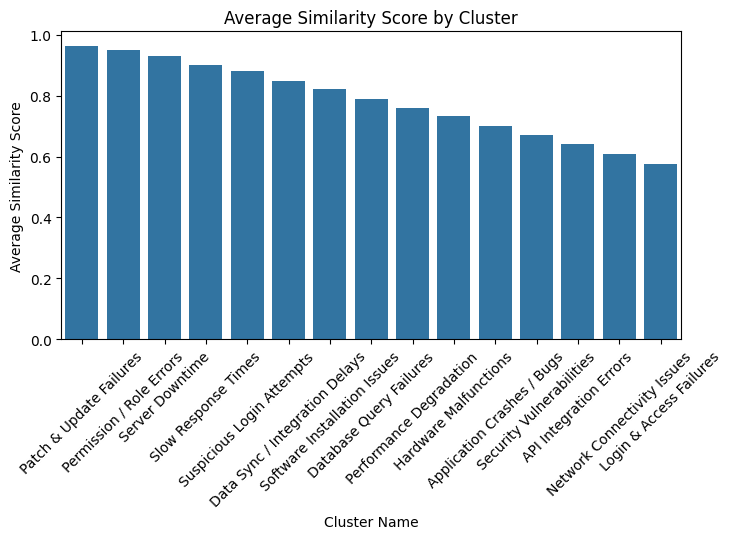

In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=avg_similarity_cluster,
    x="Cluster_Name",
    y="Similarity_Score"
)

plt.title("Average Similarity Score by Cluster")
plt.xlabel("Cluster Name")
plt.ylabel("Average Similarity Score")
plt.xticks(rotation=45)

plt.show()

In [ ]:
cluster_issue = pd.crosstab(
    df["Cluster_Name"],
    df["Category"]
)

print(cluster_issue)

Category                        Access Management   Bug  Database  Hardware  \
Cluster_Name                                                                  
API Integration Errors                          0     0         0         0   
Application Crashes / Bugs                      0  1263         0         0   
Data Sync / Integration Delays                  0     0         0         0   
Database Query Failures                         0     0       730         0   
Hardware Malfunctions                           0     0         0       557   
Login & Access Failures                      1354     0         0         0   
Network Connectivity Issues                     0     0         0         0   
Patch & Update Failures                         0     0         0         0   
Performance Degradation                         0     0         0         0   
Permission / Role Errors                      605     0         0         0   
Security Vulnerabilities                        0   

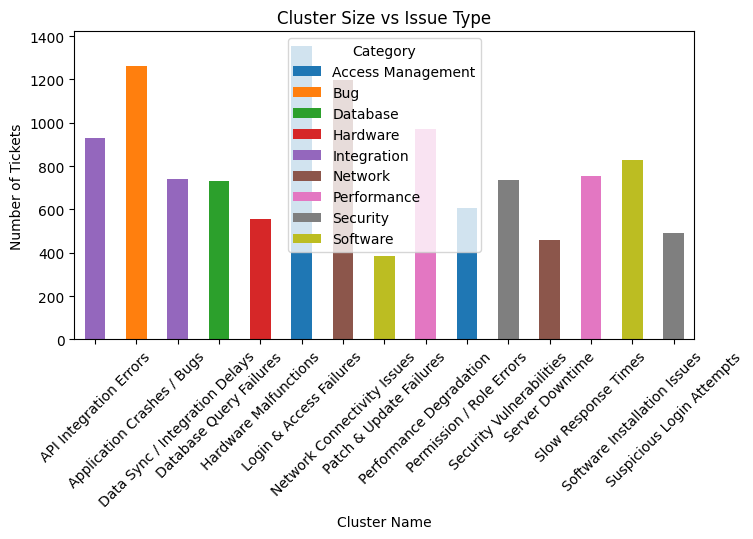

In [ ]:
cluster_issue.plot(
    kind="bar",
    stacked=True,
    figsize=(8,4)
)

plt.title("Cluster Size vs Issue Type")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

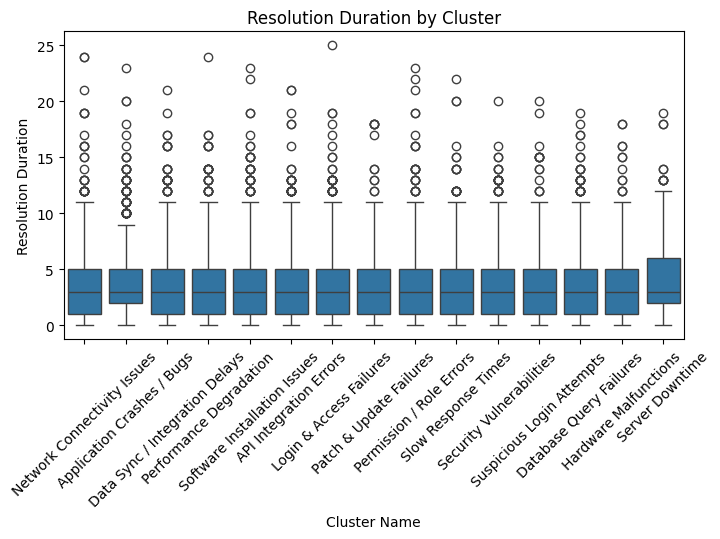

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="Cluster_Name",
    y="Resolution_Duration"
)

plt.title("Resolution Duration by Cluster")
plt.xlabel("Cluster Name")
plt.ylabel("Resolution Duration")

plt.xticks(rotation=45)

plt.show()

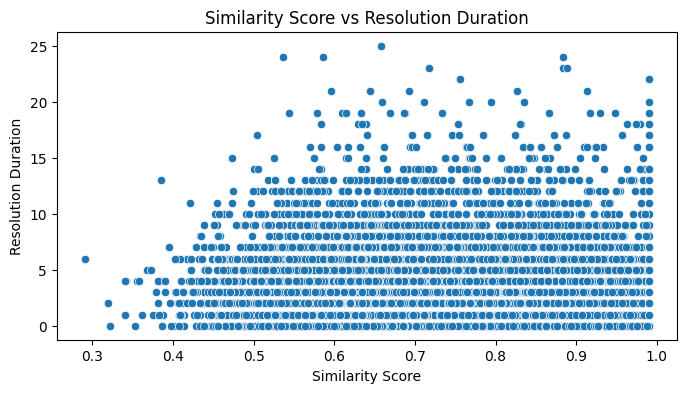

In [ ]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df,
    x="Similarity_Score",
    y="Resolution_Duration"
)

plt.title("Similarity Score vs Resolution Duration")
plt.xlabel("Similarity Score")
plt.ylabel("Resolution Duration")

plt.show()

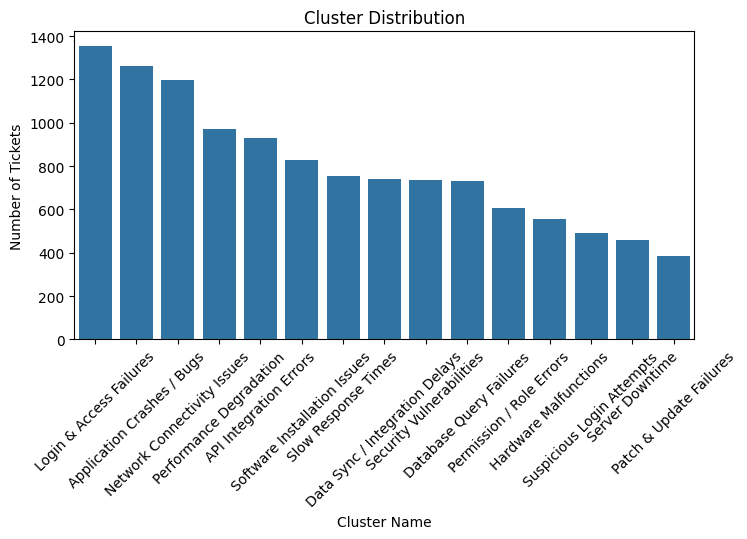

In [ ]:
cluster_counts = df["Cluster_Name"].value_counts()

plt.figure(figsize=(8,4))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

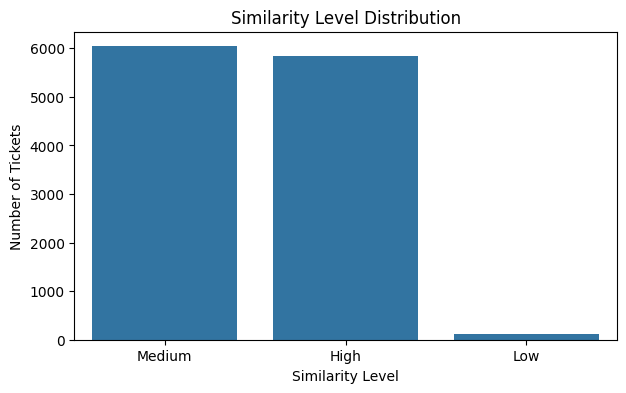

In [ ]:
similarity_counts = df["Similarity_Level"].value_counts()

plt.figure(figsize=(7,4))

sns.barplot(
    x=similarity_counts.index,
    y=similarity_counts.values
)

plt.title("Similarity Level Distribution")
plt.xlabel("Similarity Level")
plt.ylabel("Number of Tickets")

plt.show()

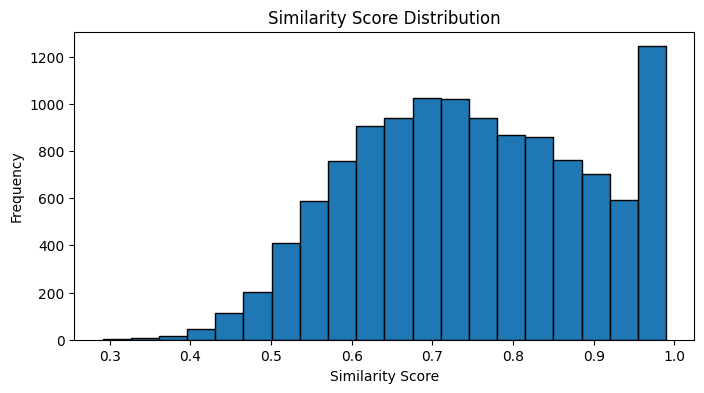

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(
    df["Similarity_Score"],
    bins=20,
    edgecolor="black"
)

plt.title("Similarity Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()

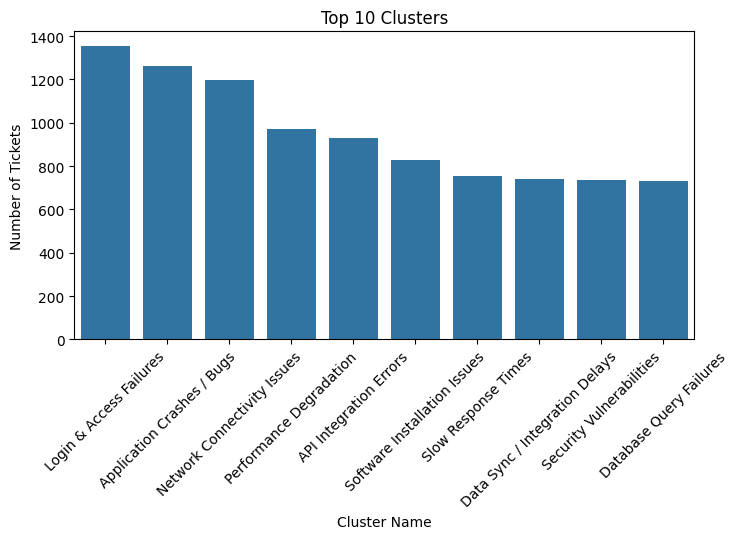

In [ ]:
top_clusters = df["Cluster_Name"].value_counts().head(10)

plt.figure(figsize=(8,4))

sns.barplot(
    x=top_clusters.index,
    y=top_clusters.values
)

plt.title("Top 10 Clusters")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

In [ ]:
cluster_table = df["Cluster_Name"].value_counts().reset_index()
cluster_table.columns = ["Cluster_Name", "Ticket_Count"]

print(cluster_table)

                      Cluster_Name  Ticket_Count
0          Login & Access Failures          1354
1       Application Crashes / Bugs          1263
2      Network Connectivity Issues          1197
3          Performance Degradation           973
4           API Integration Errors           930
5     Software Installation Issues           827
6              Slow Response Times           754
7   Data Sync / Integration Delays           739
8         Security Vulnerabilities           734
9          Database Query Failures           730
10        Permission / Role Errors           605
11           Hardware Malfunctions           557
12       Suspicious Login Attempts           493
13                 Server Downtime           458
14         Patch & Update Failures           386


In [ ]:
similarity_table = df["Similarity_Level"].value_counts().reset_index()
similarity_table.columns = ["Similarity_Level", "Ticket_Count"]

print(similarity_table)

  Similarity_Level  Ticket_Count
0           Medium          6041
1             High          5837
2              Low           122
